# 7 &middot; Time Integration: Forward Euler, Backward Euler, BDF2

To animate motion we march Newton's law $M\ddot x = -\nabla V(x)$ forward in time with a step $h$.
We compare three integrators on the same pinned cantilever beam: **Forward Euler** (explicit, order 1,
cheap but explodes unless $h$ is tiny), **Backward Euler** (implicit, order 1, stable but damps) and
**BDF2** (implicit, order 2, barely damps). Each implicit step minimizes the potential plus an inertia
term that pulls $x$ toward where momentum alone would carry it ($\tilde x$); the two implicit schemes
differ only in $\tilde x$ and the weight $c$:

$$x_{n+1} = \arg\min_x \; V(x) + \frac{c}{2h^2}\,\lVert x - \tilde x\rVert_M^2 .$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils

NOTEBOOK = "007_time_integration"                                  # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)                # results/007_time_integration/
MEDIA_DIR = "media"                                                # tracked copies for the website
# mesh
NX, NY = 14, 4                      # grid resolution (vertices along x, y)
WIDTH, HEIGHT = 2.0, 0.3            # beam size
# material and loads
MATERIAL = "macklin-mueller-neo-hookean"   # elastic energy model passed to simkit.energies.elastic_*_x
YM, PR = 500.0, 0.4                 # Young's modulus, Poisson ratio
RHO = 1.0                           # density
GRAVITY = -9.8                      # vertical gravitational acceleration
K_PIN = 1e7                         # soft-pin stiffness on the left edge
# implicit solves
NEWTON_ITERS = 30                   # max Newton iterations per implicit step
NEWTON_TOL = 1e-6                   # Newton stops when the step is shorter than this
# validation
H_CHECK = 0.01                      # timestep of the sanity checks
FD_STEP = 1e-6                      # central-difference step of the gradient check
FD_NOISE = 0.01                     # size of the random pose / velocity perturbations of the checks
SEED = 0                            # random seed of that perturbation
# order of accuracy
T_ORDER = 0.5                       # final time of the accuracy study
H_REF = 0.0003125                   # fine BDF2 reference timestep
H_ORDER = [0.02, 0.01, 0.005, 0.0025]   # timesteps whose error is measured
H_ERROR_FIELD = 0.01                # timestep whose per-vertex error is drawn
# forward vs backward Euler
H_BLOW = 0.008                      # timestep of the explicit/implicit race
H_FE_SMALL = 0.0002                 # a timestep small enough for Forward Euler to survive T_BLOW
T_BLOW = 0.3                        # its duration
BLOW_LIMIT = 1e3                    # a coordinate beyond this counts as "exploded"
N_FRAMES_BLOW, FPS_BLOW = 40, 20    # its video
# numerical damping
T_DAMP = 3.0                        # duration of the damping study
DTS = [0.001, 0.01, 0.1]            # timesteps compared
N_FRAMES_DAMP, FPS_DAMP = 60, 30    # its videos

## The beam

A $2 \times 0.3$ grid from libigl, with its left edge pinned. We also track the right-edge ("tip")
vertices to measure the swing later. Blue squares mark the pinned vertices, orange dots the tip.

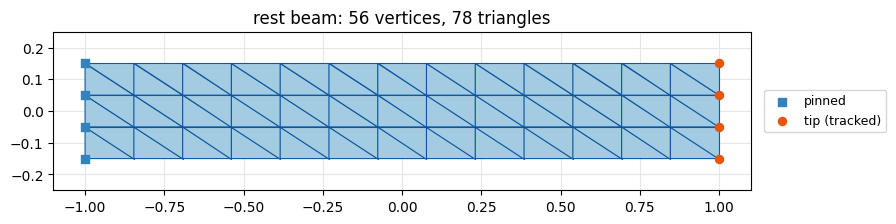

In [2]:
V_grid, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V_grid - 0.5) * np.array([WIDTH, HEIGHT])           # centered WIDTH x HEIGHT beam
n, dim = X.shape
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
tip_idx = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
x_rest = X.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 2.4))
utils.plot_mesh(ax, X, T, pins=pin_idx, title=f"rest beam: {n} vertices, {len(T)} triangles")
ax.scatter(X[tip_idx, 0], X[tip_idx, 1], s=34, color=utils.HANDLE_C, zorder=5, label="tip (tracked)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_mesh.png"))
plt.show()

## Constant operators

Everything that does not change during a simulation is built once from simkit: the deformation
Jacobian `J`, triangle areas `vol`, Lamé parameters, the (lumped, diagonal) mass matrix `M`, the gravity
force `f_g`, and the soft-pin penalty `(Q_pin, b_pin)`. The scalar fields the dynamics rely on are
drawn below: every triangle of this regular grid has the same area and the same Lamé parameters
$\mu, \lambda$, and each vertex's mass is a share of its neighbouring triangles' area, so boundary
vertices carry half the interior mass and the corners the least (darker colours).

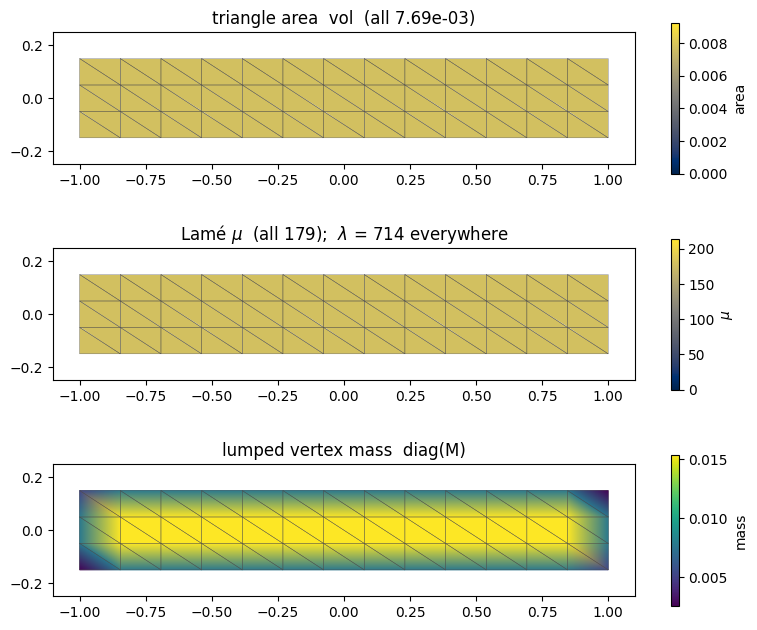

In [3]:
J = simkit.deformation_jacobian(X, T)
vol = simkit.volume(X, T)
mu_value, lam_value = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu_value)
lam = np.full((len(T), 1), lam_value)
M_vertex = simkit.massmatrix(X, T, rho=RHO)                 # (n, n) lumped mass
M = sp.sparse.kron(M_vertex, sp.sparse.eye(dim)).tocsc()     # (n*dim, n*dim)
f_g = simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)

fig, axes = plt.subplots(3, 1, figsize=(8, 6.6))
utils.plot_scalar_field(axes[0], X, T, vol, title=f"triangle area  vol  (all {vol.mean():.2e})",
                        cmap="cividis", vmin=0.0, vmax=1.2 * vol.max(), label="area")
utils.plot_scalar_field(axes[1], X, T, mu, cmap="cividis", vmin=0.0, vmax=1.2 * mu_value, label=r"$\mu$",
                        title=rf"Lamé $\mu$  (all {mu_value:.0f});  $\lambda$ = {lam_value:.0f} everywhere")
utils.plot_scalar_field(axes[2], X, T, M_vertex.diagonal(), title="lumped vertex mass  diag(M)",
                        cmap="viridis", label="mass")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "area_mass.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_area_mass.png"))
plt.show()

## The potential $V(x)$

`beam_potential_system` returns the static potential: elastic energy, the pinned left edge and gravity,
one term per line. Gravity is linear in $x$, so it has no Hessian term. Forward Euler only needs its
gradient (the force is $-\nabla V$).

In [4]:
def beam_potential_system():
    """Potential V(x) of the beam: elastic + soft pin + gravity (no inertia)."""

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_total = E_elastic + E_pin + E_gravity
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_total = g_elastic + g_pin + g_gravity
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_elastic + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

## One implicit step

`implicit_step_system(x_tilde, c, h)` is the incremental potential minimized by every implicit step: the
potential plus the inertia term $\tfrac{c}{2h^2}\lVert x-\tilde x\rVert_M^2$
(`simkit.energies.kinetic_energy` and friends, applied to $d = x - \tilde x$). It is rebuilt at every
step with that step's target.

In [5]:
def implicit_step_system(x_tilde, c, h):
    """Incremental potential of one implicit step: V(x) + c / (2 h^2) ||x - x_tilde||_M^2."""
    V_energy, V_gradient, V_hessian = beam_potential_system()

    def energy_func(x):
        E_potential = V_energy(x)
        E_inertia = simkit.energies.kinetic_energy(x - x_tilde, M, h, c)
        E_total = E_potential + E_inertia
        return E_total

    def gradient_func(x):
        g_potential = V_gradient(x)
        g_inertia = simkit.energies.kinetic_gradient(x - x_tilde, M, h, c)
        g_total = g_potential + g_inertia
        return g_total

    def hessian_func(x):
        H_potential = V_hessian(x)
        H_inertia = simkit.energies.kinetic_hessian(M, h, c)
        H_total = H_potential + H_inertia
        return H_total

    return energy_func, gradient_func, hessian_func

## The three steppers

Each maps the state (positions $x_n$, velocities $v_n$) to the next one. Only the target $\tilde x$,
the weight $c$ and the velocity update differ:

* **Forward Euler**: $x_{n+1} = x_n + h v_n$, $\;v_{n+1} = v_n - h M^{-1}\nabla V(x_n)$ (`simkit.integrators.forward_euler`, lumped mass, no solve). Pins are clamped afterwards.
* **Backward Euler**: $c = 1$, $\;\tilde x = x_n + h v_n$, $\;v_{n+1} = (x_{n+1} - x_n)/h$.
* **BDF2**: $c = \tfrac94$, $\;\tilde x = \tfrac43 x_n - \tfrac13 x_{n-1} + \tfrac{8h}{9} v_n - \tfrac{2h}{9} v_{n-1}$, $\;v_{n+1} = (3x_{n+1} - 4x_n + x_{n-1})/(2h)$.

In [6]:
pin_dofs = (pin_idx[:, None] * dim + np.arange(dim)).ravel()

def forward_euler_step(x, v, h):
    """Explicit step: read the force at x_n, no solve."""
    V_energy, V_gradient, V_hessian = beam_potential_system()
    x_next, v_next = simkit.integrators.forward_euler(x, v, V_gradient, M, h)
    x_next[pin_dofs] = x_rest[pin_dofs]                      # hard-clamp the pins
    v_next[pin_dofs] = 0.0
    return x_next, v_next

def backward_euler_step(x, v, h):
    """Implicit step with c = 1 and target x_n + h v_n."""
    x_tilde = x + h * v
    energy_func, gradient_func, hessian_func = implicit_step_system(x_tilde, 1.0, h)
    x_next = simkit.solvers.newton_solver(x_tilde, energy_func, gradient_func, hessian_func,
                                          tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True)
    v_next = (x_next - x) / h
    return x_next, v_next

def bdf2_step(x, v, x_prev, v_prev, h):
    """Implicit step with c = 9/4 and the second-order BDF2 target."""
    x_tilde = (4 / 3) * x - (1 / 3) * x_prev + (8 * h / 9) * v - (2 * h / 9) * v_prev
    energy_func, gradient_func, hessian_func = implicit_step_system(x_tilde, 9 / 4, h)
    x_next = simkit.solvers.newton_solver(x_tilde, energy_func, gradient_func, hessian_func,
                                          tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True)
    v_next = (3 * x_next - 4 * x + x_prev) / (2 * h)
    return x_next, v_next

## Sanity checks

Three cheap checks before simulating: the step gradient matches a central finite difference
(`simkit.gradient_cfd`) at a random pose; our Backward Euler step from a random velocity matches the
library's `simkit.integrators.backward_euler` (same Newton solve); and Newton converges on the first
step from rest. Expect a gradient error near $10^{-7}$ and a difference at rounding level. The plot shows
$\lVert\nabla E\rVert$ after each Newton step; Newton stops once its step is shorter than `NEWTON_TOL`.
At $h = 0.001$ and $0.1$ the gradient drops by 8 and 4 orders of magnitude. At $h = 0.01$ the line search
stalls after one step at $\approx 8\cdot10^{-4}$ (the remaining decrease is below the rounding error of
the total energy), still 1000 times below the start and ample for one timestep.

gradient check: relative error 6.45e-08
our BE step vs simkit.integrators.backward_euler: max difference 1.1e-16 (the step itself moves vertices by up to 1.0e-03)


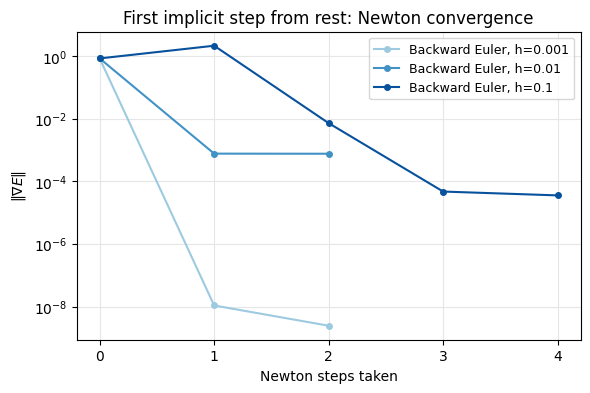

In [7]:
rng = np.random.default_rng(SEED)
x_test = x_rest + FD_NOISE * rng.standard_normal(x_rest.shape)
energy_func, gradient_func, hessian_func = implicit_step_system(x_rest, 1.0, H_CHECK)
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
g_an = gradient_func(x_test).ravel()
print(f"gradient check: relative error {np.linalg.norm(g_fd - g_an) / np.linalg.norm(g_an):.2e}")

v_test = FD_NOISE * rng.standard_normal(x_rest.shape)
x_ours, _ = backward_euler_step(x_rest, v_test, H_CHECK)
V_energy, V_gradient, V_hessian = beam_potential_system()
x_lib = simkit.integrators.backward_euler(x_rest, x_rest - H_CHECK * v_test, V_energy, V_gradient,
                                          V_hessian, M, H_CHECK, tolerance=NEWTON_TOL,
                                          max_iter=NEWTON_ITERS, do_line_search=True)
print(f"our BE step vs simkit.integrators.backward_euler: max difference {np.abs(x_ours - x_lib).max():.1e} "
      f"(the step itself moves vertices by up to {np.abs(x_ours - x_rest).max():.1e})")

fig, ax = plt.subplots(figsize=(6.5, 4))
for h, col in zip(DTS, ["#9ecae1", "#4292c6", "#08519c"]):
    energy_func, gradient_func, hessian_func = implicit_step_system(x_rest, 1.0, h)
    x_final, info = simkit.solvers.newton_solver(x_rest.copy(), energy_func, gradient_func, hessian_func,
                                                 tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS,
                                                 do_line_search=True, return_info=True)
    g_norms = [np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x_final))]
    ax.semilogy(g_norms, "-o", ms=4, color=col, label=f"Backward Euler, h={h}")
ax.set_xlabel("Newton steps taken"); ax.set_ylabel(r"$\|\nabla E\|$")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("First implicit step from rest: Newton convergence")
ax.grid(True, which="both", color="0.9"); ax.legend(fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_newton_convergence.png"))
plt.show()

## A driver that records every step

`simulate` releases the beam from rest and takes **exactly** `round(T/h)` steps, so every timestep ends
at the same final time. It records all positions and velocities; BDF2 needs one step of history, so its
first step is a Backward Euler step. A run that blows up (non-finite, or beyond `BLOW_LIMIT`) stops early.
A short recorded BDF2 run then cross-checks `bdf2_step` against `simkit.integrators.bdf2`, which rebuilds
both velocities from the last four positions; the two should agree to rounding.

In [8]:
def simulate(scheme, h, T_total):
    """Integrate from rest with `scheme`; return times (K,), positions and velocities (K, n*dim)."""
    x, v = x_rest.copy(), np.zeros_like(x_rest)
    x_prev, v_prev = x, v
    xs, vs = [x], [v]
    for k in range(int(round(T_total / h))):
        if scheme == "Forward Euler":
            x_next, v_next = forward_euler_step(x, v, h)
        elif scheme == "Backward Euler" or k == 0:           # BDF2 bootstraps with one BE step
            x_next, v_next = backward_euler_step(x, v, h)
        else:
            x_next, v_next = bdf2_step(x, v, x_prev, v_prev, h)
        x_prev, v_prev, x, v = x, v, x_next, v_next
        xs.append(x); vs.append(v)
        if not np.isfinite(x).all() or np.abs(x).max() > BLOW_LIMIT:
            break
    ts = h * np.arange(len(xs))
    return ts, np.hstack(xs).T, np.hstack(vs).T

_, xs_check, vs_check = simulate("BDF2", H_CHECK, 4 * H_CHECK)       # states x_0 .. x_4
x_hist = [x.reshape(-1, 1) for x in xs_check[::-1]]                   # x_4, x_3, x_2, x_1, x_0
v_hist = [v.reshape(-1, 1) for v in vs_check[::-1]]
x_ours, _ = bdf2_step(x_hist[0], v_hist[0], x_hist[1], v_hist[1], H_CHECK)
V_energy, V_gradient, V_hessian = beam_potential_system()
x_lib = simkit.integrators.bdf2(x_hist[0], x_hist[1], x_hist[2], x_hist[3], V_energy, V_gradient, V_hessian,
                                M, H_CHECK, tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS, do_line_search=True)
print(f"our BDF2 step vs simkit.integrators.bdf2: max difference {np.abs(x_ours - x_lib).max():.1e} "
      f"(the step itself moves vertices by up to {np.abs(x_ours - x_hist[0]).max():.1e})")

our BDF2 step vs simkit.integrators.bdf2: max difference 0.0e+00 (the step itself moves vertices by up to 4.5e-03)


## Order of accuracy, measured on our beam

We run the beam to $T = 0.5$ at four timesteps and compare the final pose with a fine-timestep BDF2
reference on the same mesh. On a log-log plot an order-$p$ method is a line of slope $p$. Forward Euler
is left out: it needs a far smaller $h$ just to stay stable, as we'll see next.

Backward Euler   errors [0.0985 0.0657 0.0399 0.0228]   fitted order 0.70   slope between the two smallest h 0.81
BDF2             errors [0.041  0.0144 0.0044 0.0011]   fitted order 1.72   slope between the two smallest h 1.95


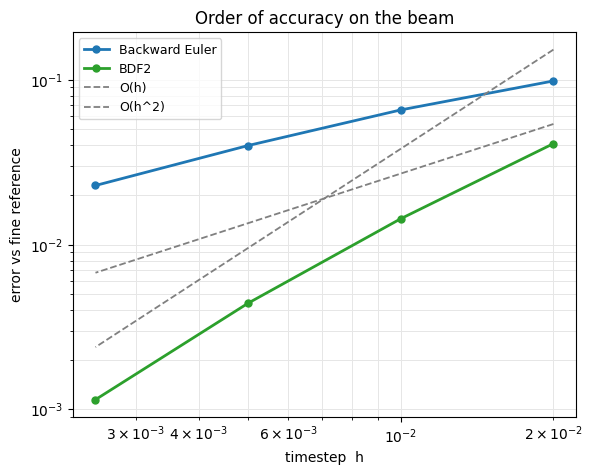

In [9]:
_, xs_ref, _ = simulate("BDF2", H_REF, T_ORDER)
x_ref = xs_ref[-1]
final = {(scheme, h): simulate(scheme, h, T_ORDER)[1][-1]
         for scheme in ["Backward Euler", "BDF2"] for h in H_ORDER}
errors = {scheme: np.array([np.linalg.norm(final[scheme, h] - x_ref) for h in H_ORDER])
          for scheme in ["Backward Euler", "BDF2"]}
for scheme, e in errors.items():
    fitted = np.polyfit(np.log(H_ORDER), np.log(e), 1)[0]
    last_pair = np.log(e[-2] / e[-1]) / np.log(H_ORDER[-2] / H_ORDER[-1])
    print(f"{scheme:16s} errors {np.array2string(e, precision=4)}   fitted order {fitted:.2f}   "
          f"slope between the two smallest h {last_pair:.2f}")

fig, ax = utils.loglog_plot(H_ORDER, errors, xlabel="timestep  h", ylabel="error vs fine reference",
                            colors=utils.INTEGRATOR_COLORS, ref_slopes={"O(h)": 1, "O(h^2)": 2},
                            title="Order of accuracy on the beam")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "order_of_accuracy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_order_of_accuracy.png"))
plt.show()

BDF2 is both more accurate and steeper. The fitted slopes (0.70, 1.72) sit below 1 and 2 because the
largest timesteps are not yet asymptotic; between the two smallest they are 0.81 and 1.95. Where on the
beam does the error live? Below is the per-vertex error $\lVert x_i - x_i^{\text{ref}}\rVert$ at
$h = 0.01$, on the reference pose with a shared color scale: it is largest near the free tip, and
BDF2's is about four times smaller.

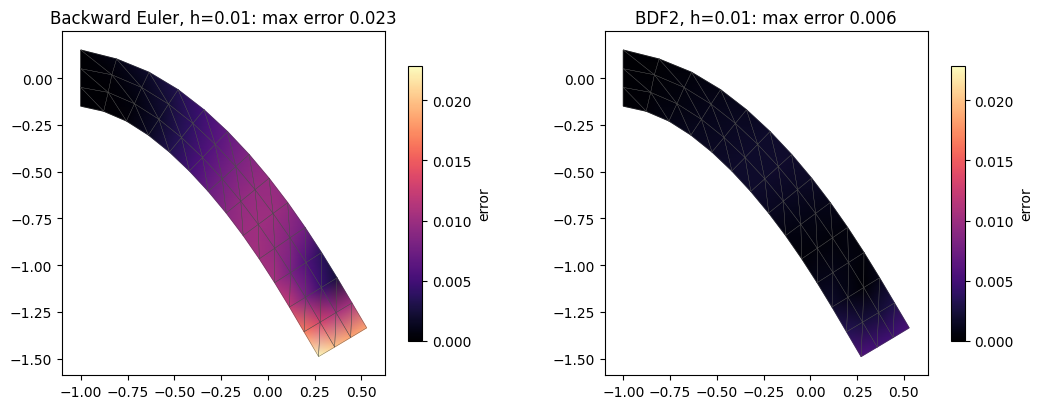

In [10]:
X_ref = x_ref.reshape(n, dim)
err_fields = {scheme: np.linalg.norm((final[scheme, H_ERROR_FIELD] - x_ref).reshape(n, dim), axis=1)
              for scheme in ["Backward Euler", "BDF2"]}
vmax = max(e.max() for e in err_fields.values())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (scheme, e) in zip(axes, err_fields.items()):
    utils.plot_scalar_field(ax, X_ref, T, e, vmin=0.0, vmax=vmax, cmap="magma", label="error",
                            title=f"{scheme}, h={H_ERROR_FIELD}: max error {e.max():.3f}")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "error_field.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_error_field.png"))
plt.show()

## Forward Euler explodes; Backward Euler doesn't

On a vibration mode of frequency $\omega$, one Forward Euler step multiplies the amplitude by
$\sqrt{1 + \omega^2 h^2} > 1$, so the stiffest mode ($\omega_{\max}$ of $K u = \omega^2 M u$ at rest)
grows fastest. We compute it and run both integrators at $h = 0.008$. Left, the largest vertex
displacement: Forward Euler follows Backward Euler while its unstable stiff modes are still tiny, then
shoots up from $t \approx 0.07$ s and leaves the scene after 13 steps. It survives the same 0.3 s only
at $h = 0.0002$ (dotted, on top of Backward Euler), a timestep 40 times smaller. Right, the amplitude
$a = \sqrt{q^2 + (\dot q/\omega_{\max})^2}$ of the stiffest mode $u_{\max}$ itself, with
$q = u_{\max}^\top M (x - X)$: it grows at the predicted rate from the very first step.

omega_max = 733 rad/s  ->  Forward Euler amplifies it x5.95 per step at h=0.008
measured: the stiffest mode grows x5.98 per step (median), FE leaves the scene after 13 steps


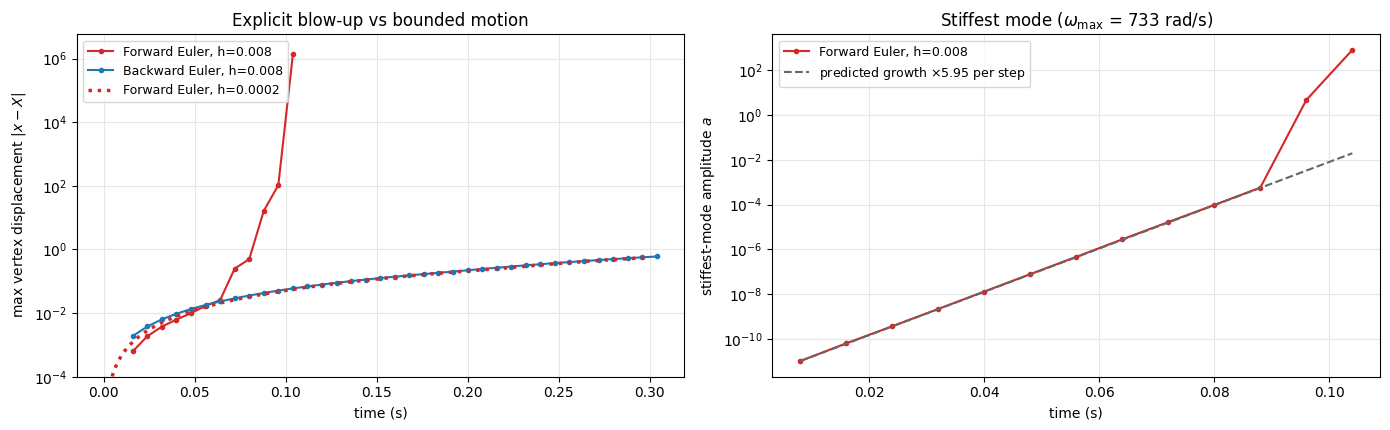

In [11]:
free = np.setdiff1d(np.arange(n * dim), pin_dofs)
M_free = M[free][:, free]
K_rest = simkit.energies.elastic_hessian_x(X, J, mu, lam, vol, MATERIAL, psd=True)[free][:, free]
omega_sq, U = sp.linalg.eigh(K_rest.toarray(), M_free.toarray())      # K u = omega^2 M u, M-orthonormal u
omega_max, u_max = np.sqrt(omega_sq[-1]), U[:, -1]
growth = np.sqrt(1 + (omega_max * H_BLOW) ** 2)
print(f"omega_max = {omega_max:.0f} rad/s  ->  Forward Euler amplifies it x{growth:.2f} per step at h={H_BLOW}")

runs_blow = {scheme: simulate(scheme, H_BLOW, T_BLOW) for scheme in ["Forward Euler", "Backward Euler"]}
ts_small, xs_small, _ = simulate("Forward Euler", H_FE_SMALL, T_BLOW)
ts_fe, xs_fe, vs_fe = runs_blow["Forward Euler"]
q = np.array([u_max @ (M_free @ (x - x_rest.ravel())[free]) for x in xs_fe])    # stiffest-mode coordinate
q_dot = np.array([u_max @ (M_free @ v[free]) for v in vs_fe])                   # and its velocity
amp = np.hypot(q, q_dot / omega_max)
print(f"measured: the stiffest mode grows x{np.median(amp[2:] / amp[1:-1]):.2f} per step (median), "
      f"FE leaves the scene after {len(ts_fe) - 1} steps")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
ax = axes[0]
for scheme, (ts, xs, _) in runs_blow.items():
    disp = np.abs(xs - x_rest.ravel()).max(axis=1)
    ax.semilogy(ts[2:], disp[2:], "-o", ms=3, color=utils.INTEGRATOR_COLORS[scheme], label=f"{scheme}, h={H_BLOW}")
disp_small = np.abs(xs_small - x_rest.ravel()).max(axis=1)
ax.semilogy(ts_small[2:], disp_small[2:], ":", lw=2.5, color=utils.INTEGRATOR_COLORS["Forward Euler"],
            zorder=4, label=f"Forward Euler, h={H_FE_SMALL}")
ax.set_xlabel("time (s)"); ax.set_ylabel(r"max vertex displacement $|x - X|$")
ax.set_title("Explicit blow-up vs bounded motion"); ax.set_ylim(bottom=1e-4)
ax.grid(True, which="both", color="0.9"); ax.legend(fontsize=9, loc="upper left")
ax = axes[1]
k = np.arange(1, len(ts_fe))
ax.semilogy(ts_fe[k], amp[k], "-o", ms=3, color=utils.INTEGRATOR_COLORS["Forward Euler"],
            label=f"Forward Euler, h={H_BLOW}")
ax.semilogy(ts_fe[k], amp[1] * growth ** (k - 1), "--", color="0.4",
            label=rf"predicted growth $\times{growth:.2f}$ per step")
ax.set_xlabel("time (s)"); ax.set_ylabel(r"stiffest-mode amplitude $a$")
ax.set_title(rf"Stiffest mode ($\omega_{{\max}}$ = {omega_max:.0f} rad/s)")
ax.grid(True, which="both", color="0.9"); ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "fe_growth.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_fe_growth.png"))
plt.show()

The same two runs side by side: Forward Euler flies apart after about 0.1 s, while Backward Euler
calmly sags under gravity. This is why stiff elasticity is integrated implicitly.

In [12]:
sample_blow = np.linspace(0, T_BLOW, N_FRAMES_BLOW)
panels = [{"states": utils.states_at_times(ts, xs.reshape(-1, n, dim), sample_blow), "T": T,
           "title": f"{scheme}  h={H_BLOW}" + ("  (EXPLODES)" if scheme == "Forward Euler" else "  (stable)")}
          for scheme, (ts, xs, _) in runs_blow.items()]
lims_blow = utils.auto_limits([runs_blow["Backward Euler"][1].reshape(-1, dim)], pad=0.3)   # frame the stable run
fig, anim = utils.animate_meshes_grid(panels, lims=lims_blow, fps=FPS_BLOW,
                                      suptitle="Same timestep: explicit blows up, implicit is fine")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "fe_vs_be.mp4"), fps=FPS_BLOW,
                                         copy_to=os.path.join(MEDIA_DIR, "007_fe_vs_be.mp4"))
plt.close(fig)
utils.embed_video(video)

## Numerical damping: the timestep changes perceived stiffness

Release the beam under gravity and step **Backward Euler** for 3 s at $h$ = 0.001, 0.01 and 0.1. The
physics is identical, yet the larger the step, the more artificial damping: the swing dies out faster
and the material looks stiffer. The cell simulates BDF2 at the same timesteps too, for the next sections.

In [13]:
sample_damp = np.linspace(0, T_DAMP, N_FRAMES_DAMP)
runs = {(scheme, h): simulate(scheme, h, T_DAMP) for scheme in ["Backward Euler", "BDF2"] for h in DTS}
lims_damp = utils.auto_limits([xs.reshape(-1, dim) for _, xs, _ in runs.values()], pad=0.15)

panels = [{"states": utils.states_at_times(runs["Backward Euler", h][0],
                                           runs["Backward Euler", h][1].reshape(-1, n, dim), sample_damp),
           "T": T, "title": f"Backward Euler  h={h}"} for h in DTS]
fig, anim = utils.animate_meshes_grid(panels, lims=lims_damp, fps=FPS_DAMP,
                                      suptitle="Backward Euler: bigger timestep -> more numerical damping")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "be_damping.mp4"), fps=FPS_DAMP,
                                         copy_to=os.path.join(MEDIA_DIR, "007_be_damping.mp4"))
plt.close(fig)
utils.embed_video(video)

## BDF2 barely damps

The same three timesteps with **BDF2**: it keeps swinging at all of them. Second-order accuracy buys
far less numerical dissipation than Backward Euler.

In [14]:
panels = [{"states": utils.states_at_times(runs["BDF2", h][0], runs["BDF2", h][1].reshape(-1, n, dim),
                                           sample_damp),
           "T": T, "title": f"BDF2  h={h}"} for h in DTS]
fig, anim = utils.animate_meshes_grid(panels, lims=lims_damp, fps=FPS_DAMP,
                                      suptitle="BDF2: much less numerical damping at the same timesteps")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "bdf2_damping.mp4"), fps=FPS_DAMP,
                                         copy_to=os.path.join(MEDIA_DIR, "007_bdf2_damping.mp4"))
plt.close(fig)
utils.embed_video(video)

The two videos as one plot: the vertical position of the tip (mean of the orange vertices) over time.
At $h = 0.001$ both schemes agree. As $h$ grows, Backward Euler's rebound shrinks (to about a third at
$h = 0.1$), while BDF2 keeps most of it even there.

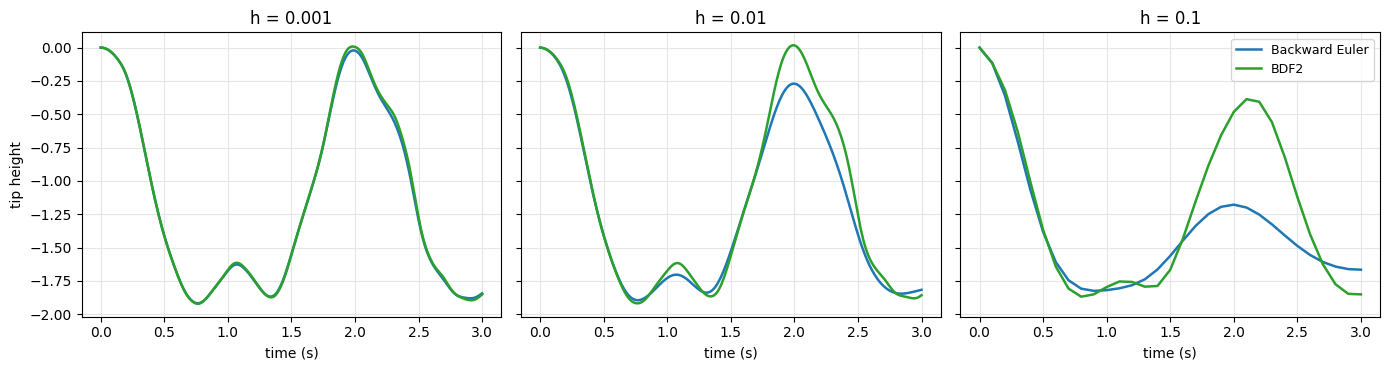

In [15]:
fig, axes = plt.subplots(1, len(DTS), figsize=(14, 3.8), sharey=True)
for ax, h in zip(axes, DTS):
    for scheme in ["Backward Euler", "BDF2"]:
        ts, xs, _ = runs[scheme, h]
        tip_y = xs.reshape(-1, n, dim)[:, tip_idx, 1].mean(axis=1)
        ax.plot(ts, tip_y, color=utils.INTEGRATOR_COLORS[scheme], lw=1.8, label=scheme)
    ax.set_title(f"h = {h}"); ax.set_xlabel("time (s)"); ax.grid(True, color="0.9")
axes[0].set_ylabel("tip height"); axes[-1].legend(fontsize=9, loc="upper right")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_trajectory.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_tip_trajectory.png"))
plt.show()

## The damping, quantified: total energy bleeds away

The artificial damping removes **mechanical energy**. We track elastic + gravitational + kinetic energy
(the pins do no work) along the same runs. For Backward Euler, the bigger the timestep, the faster the
energy drops; BDF2 (dashed) holds on to far more of it at every timestep.

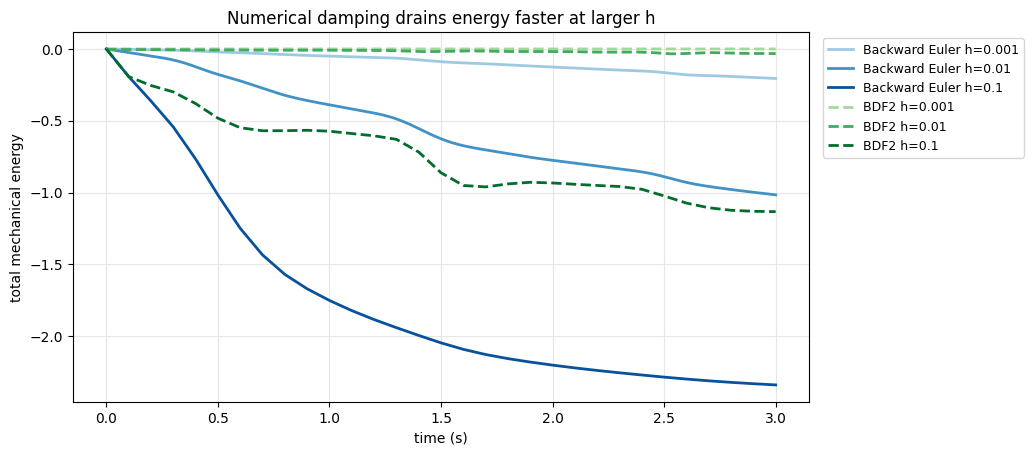

In [16]:
def mechanical_energy(x, v):
    """Elastic + gravitational + kinetic energy of one state (x, v)."""
    E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
    E_gravity = -(f_g.T @ x).item()
    E_kinetic = 0.5 * (v.T @ M @ v).item()
    E_total = E_elastic + E_gravity + E_kinetic
    return E_total

fig, ax = plt.subplots(figsize=(9.5, 4.8))
shades = {"Backward Euler": ["#9ecae1", "#4292c6", "#08519c"], "BDF2": ["#a1d99b", "#41ab5d", "#006d2c"]}
for (scheme, h), (ts, xs, vs) in runs.items():
    E = [mechanical_energy(x.reshape(-1, 1), v.reshape(-1, 1)) for x, v in zip(xs, vs)]
    ax.plot(ts, E, color=shades[scheme][DTS.index(h)], lw=2, ls="-" if scheme == "Backward Euler" else "--",
            label=f"{scheme} h={h}")
ax.set_xlabel("time (s)"); ax.set_ylabel("total mechanical energy")
ax.set_title("Numerical damping drains energy faster at larger h")
ax.grid(True, color="0.9"); ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "007_energy.png"))
plt.show()

### Takeaways
* **Backward Euler** is order 1 and **BDF2** order 2, measured on the beam itself.
* **Forward Euler** amplifies the stiffest mode every step and explodes at a timestep the implicit methods handle easily.
* **Backward Euler** damps motion (and drains total energy) more as $h$ grows; **BDF2** stays lively and keeps far more energy.
* Every implicit step is one Newton solve of $V(x) + \tfrac{c}{2h^2}\lVert x - \tilde x\rVert_M^2$; only $\tilde x$ and $c$ change.